# Imports

In [31]:
import os
import csv
import pandas as pd
import matplotlib.pyplot as plt

# Load of data

In [19]:
df_cancelled = pd.read_csv("../Data and descriptions/Case Rigshospitalet - Cancelled operations.csv", sep=';')
df_complete = pd.read_csv("../Data and descriptions/Case Rigshospitalet - Completed operations.csv", sep = ';')

C:\Users\Bruger\AppData\Local\Temp\ipykernel_12356\3600004165.py:2: DtypeWarning: Columns (13,14,21,22,23,24,25,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df_complete = pd.read_csv("../Data and descriptions/Case Rigshospitalet - Completed operations.csv", sep = ';')


In [20]:
# remove columns with staff and resources
df_complete_wo = df_complete.drop(columns=[col for col in df_complete.columns if col.startswith("Ressource")])
df_complete_wo = df_complete_wo.drop(columns=[col for col in df_complete_wo.columns if col.startswith("Staff")])
df_complete_wo.describe()

,Case-ID Anonymous,Patient Alder,Operationsgang ID,Forsinkelse (minutter),Overskredet (minutter)
count,133158.000000,133158.000000,133158.000000,132491.000000,132537.000000
mean,60156.037437,53.788244,40663.550909,20.511642,25.346198
std,34927.061620,24.889920,52262.972747,50.977296,68.894706
min,1.000000,0.000000,618.000000,-3045.000000,-3003.000000
25%,29928.250000,34.000000,622.000000,0.000000,-10.000000
50%,60097.500000,61.000000,625.000000,14.000000,23.000000
75%,90338.750000,74.000000,107621.000000,40.000000,57.000000
max,120868.000000,107.000000,133218.000000,1585.000000,1560.000000


In [21]:
# Make datetime objects
df_complete_wo['Dato'] = pd.to_datetime(df_complete_wo['Dato'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Pt ankommet til hospitalet'] = pd.to_datetime(df_complete_wo['Pt ankommet til hospitalet'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Planlagt stue klargøring start'] = pd.to_datetime(df_complete_wo['Planlagt stue klargøring start'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Stue klargøring start'] = pd.to_datetime(df_complete_wo['Stue klargøring start'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Stue klargjort'] = pd.to_datetime(df_complete_wo['Stue klargjort'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Patient på stuen'] = pd.to_datetime(df_complete_wo['Patient på stuen'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Patient på stuen (Planlagt)'] = pd.to_datetime(df_complete_wo['Patient på stuen (Planlagt)'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Anæstesistart'] = pd.to_datetime(df_complete_wo['Anæstesistart'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Anæstesi melder klar'] = pd.to_datetime(df_complete_wo['Anæstesi melder klar'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Procedure start'] = pd.to_datetime(df_complete_wo['Procedure start'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Procedure slut'] = pd.to_datetime(df_complete_wo['Procedure slut'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Patient klar til afgang'] = pd.to_datetime(df_complete_wo['Patient klar til afgang'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Patient forlader stuen (Planlagt)'] = pd.to_datetime(df_complete_wo['Patient forlader stuen (Planlagt)'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Patient forlader stuen'] = pd.to_datetime(df_complete_wo['Patient forlader stuen'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Stue rengjort (Planlagt)'] = pd.to_datetime(df_complete_wo['Stue rengjort (Planlagt)'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Stue rengøring start'] = pd.to_datetime(df_complete_wo['Stue rengøring start'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Stue rengjort'] = pd.to_datetime(df_complete_wo['Stue rengjort'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['I opvågning'] = pd.to_datetime(df_complete_wo['I opvågning'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Anæstesistop'] = pd.to_datetime(df_complete_wo['Anæstesistop'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Klar til udskrivelse efter opvågning'] = pd.to_datetime(df_complete_wo['Klar til udskrivelse efter opvågning'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Patient forlader afdeling'] = pd.to_datetime(df_complete_wo['Patient forlader afdeling'], format='%Y-%m-%d %H:%M:%S,%f')

In [28]:
df_complete_wo.keys()

Index(['Case-ID Anonymous', 'Patient Alder', 'Speciale', 'Stue',
       'Operationsgang ID', 'Akut case (J/N)', 'Dato',
       'Pt ankommet til hospitalet', 'Planlagt stue klargøring start',
       'Stue klargøring start', 'Stue klargjort',
       'Patient på stuen (Planlagt)', 'Patient på stuen', 'Anæstesistart',
       'Anæstesi melder klar', 'Procedure start', 'Procedure slut',
       'Patient klar til afgang', 'Patient forlader stuen (Planlagt)',
       'Patient forlader stuen', 'Stue rengjort (Planlagt)',
       'Stue rengøring start', 'Stue rengjort', 'I opvågning', 'Anæstesistop',
       'Klar til udskrivelse efter opvågning', 'Patient forlader afdeling',
       'Forsinkelse (minutter)', 'Overskredet (minutter)', 'Forsinkelsesårsag',
       'Procedure - Tekst & ID', 'Aktionsdiagnose - Kode & tekst',
       'Aktionsdiagnose - Gruppe'],
      dtype='object')

# Clustering

In [29]:
df_complete_cluster = df_complete_wo = df_complete_wo.drop(columns=['Dato',
       'Pt ankommet til hospitalet', 'Planlagt stue klargøring start',
       'Stue klargøring start', 'Stue klargjort',
       'Patient på stuen (Planlagt)', 'Patient på stuen', 'Anæstesistart',
       'Anæstesi melder klar', 'Procedure start', 'Procedure slut',
       'Patient klar til afgang', 'Patient forlader stuen (Planlagt)',
       'Patient forlader stuen', 'Stue rengjort (Planlagt)',
       'Stue rengøring start', 'Stue rengjort', 'I opvågning', 'Anæstesistop',
       'Klar til udskrivelse efter opvågning', 'Patient forlader afdeling','Forsinkelsesårsag'])

In [37]:
df_complete_cluster

,Case-ID Anonymous,Patient Alder,Speciale,Stue,Operationsgang ID,Akut case (J/N),Forsinkelse (minutter),Overskredet (minutter),Procedure - Tekst & ID,Aktionsdiagnose - Kode & tekst,Aktionsdiagnose - Gruppe
0,28,29,Øre-næse-hals,OPNORD 23.240 (H),107621,Nej,95.0,36.0,AURES ALATAE [1070010290],DQ175: Aures alatae,"Medfødte misdannelser i øje, øre, ansigtet og ..."
1,197,60,Plastikkirurgi,OPNORD 13.114 (H),107621,Nej,8.0,30.0,"ARKORREKTION, TRUNCUS -LA [1070012770]",DZ421: Kontakt mhp. plastikkirurgisk efterbeha...,Personer i kontakt med sundhedsvæsenet med hen...
2,197,60,Plastikkirurgi,OPNORD 13.114 (H),107621,Nej,8.0,30.0,"BRYSTKORREKTION VED ASYMMETRI -LA, LIPOINJEKTI...",DZ421: Kontakt mhp. plastikkirurgisk efterbeha...,Personer i kontakt med sundhedsvæsenet med hen...
3,230,12,Plastikkirurgi,OPNORD 13.110 (H),107621,Nej,16.0,-3.0,"ARKORREKTION, HOVED OG HALS LA [1070010676]",DZ429: Kontakt mhp. plastikkirurgisk efterbeha...,Personer i kontakt med sundhedsvæsenet med hen...
4,238,57,Plastikkirurgi,OPNORD 301,107621,Nej,16.0,1.0,"EXCISION, BENIGN TUMOR, TRUNCUS -LA [1070010711]",DQ850: Ikke-malign neurofibromatose,Andre medfødte misdannelser
...,...,...,...,...,...,...,...,...,...,...,...
133153,120283,59,Øjenkirurgi,GLO Ø 46 STUE 07,625,Nej,47.0,51.0,FAKO 2 - LA [1070010663],DH259: Aldersbetinget grå stær (>=50 år) UNS,Sygdomme i øjets linse
133154,120284,58,Øjenkirurgi,GLO Ø 46 STUE 07,625,Nej,35.0,40.0,FAKO 3 - LA [1070010664],DH259: Aldersbetinget grå stær (>=50 år) UNS,Sygdomme i øjets linse
133155,120291,70,Øjenkirurgi,GLO Ø 36 STUE 05,625,Nej,52.0,52.0,FAKO 3 - LA [1070010664],DH259: Aldersbetinget grå stær (>=50 år) UNS,Sygdomme i øjets linse
133156,120337,87,Øjenkirurgi,GLO Ø 36 STUE 05,625,Nej,42.0,50.0,FAKO - LA BILATERAL [1070015679],DH259: Aldersbetinget grå stær (>=50 år) UNS,Sygdomme i øjets linse


# Lidt generelt statistik

(array([1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 6.0000e+00,
        3.0000e+00, 1.0000e+00, 2.0000e+00, 0.0000e+00, 3.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 5.0000e+00, 1.0000e+00, 0.0000e+00,
        5.0000e+00, 6.0000e+00, 1.4000e+01, 2.1000e+01, 3.0000e+01,
        5.6000e+01, 1.3100e+02, 3.4500e+02, 1.2230e+03, 5.5410e+03,
        5.0813e+04, 5.4671e+04, 1.4938e+04, 3.0290e+03, 8.6400e+02,
        3.5700e+02, 1.8200e+02, 9.8000e+01, 6.00

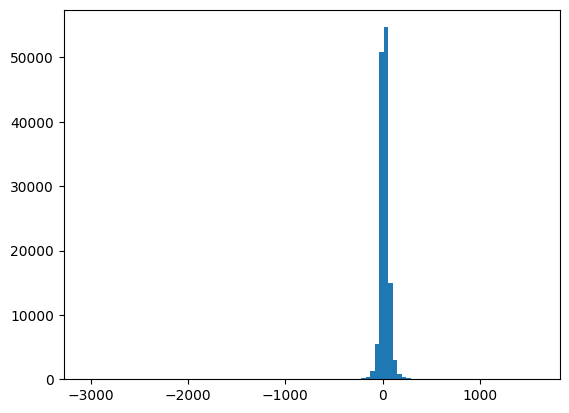

In [36]:
plt.hist(df_complete['Forsinkelse (minutter)'],bins=100)

In [ ]:
# Forsinkelser aggregated efter specialer. 
dfs = {k: v for k, v in df_complete.groupby('Speciale')}
for i in dfs.keys():
    print(i,":")
    print("Gennemsnitlig forsinkelse:", dfs[i]['Forsinkelse (minutter)'].mean())
    print("Std forsinkelse",dfs[i]['Forsinkelse (minutter)'].std() )

618 :
Gennemsnitlig forsinkelse: 19.734461079784822
Std forsinkelse 57.935160559714056
620 :
Gennemsnitlig forsinkelse: 3.5016522988505745
Std forsinkelse 68.28250481827159
622 :
Gennemsnitlig forsinkelse: -6.880137304017071
Std forsinkelse 73.31460482158
624 :
Gennemsnitlig forsinkelse: 11.40927583401139
Std forsinkelse 35.29337165548513
625 :
Gennemsnitlig forsinkelse: 41.124303058725445
Std forsinkelse 37.408650781360045
107621 :
Gennemsnitlig forsinkelse: 15.848547152518021
Std forsinkelse 41.563070783867765
107622 :
Gennemsnitlig forsinkelse: 18.49012327342938
Std forsinkelse 37.3490357885074
133218 :
Gennemsnitlig forsinkelse: 20.24350483953133
Std forsinkelse 22.377103539941444


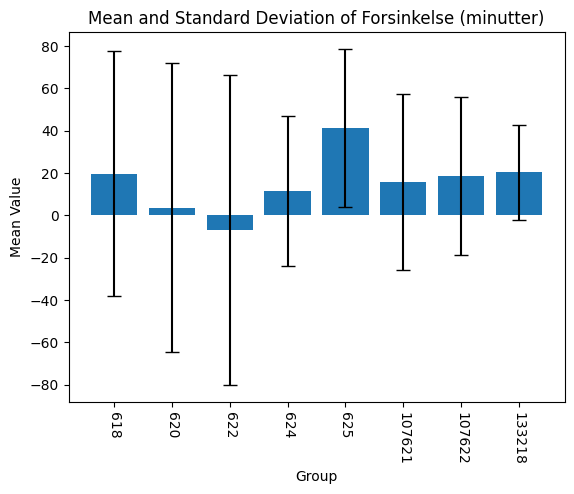

In [50]:
dfs = {k: v for k, v in df_complete.groupby('Operationsgang ID')}
column = 'Forsinkelse (minutter)'

keys = []
means = []
stds = []

for k, d in dfs.items():
    keys.append(k)
    means.append(d[column].mean())
    stds.append(d[column].std())

plt.figure()
keys_str = [str(k) for k in keys]
plt.bar(keys_str, means, yerr=stds, capsize=5)

plt.xlabel("Group")
plt.ylabel("Mean Value")
plt.title(f"Mean and Standard Deviation of {column}")
plt.xticks(rotation=-90)

plt.show()

## Further investigation of 625

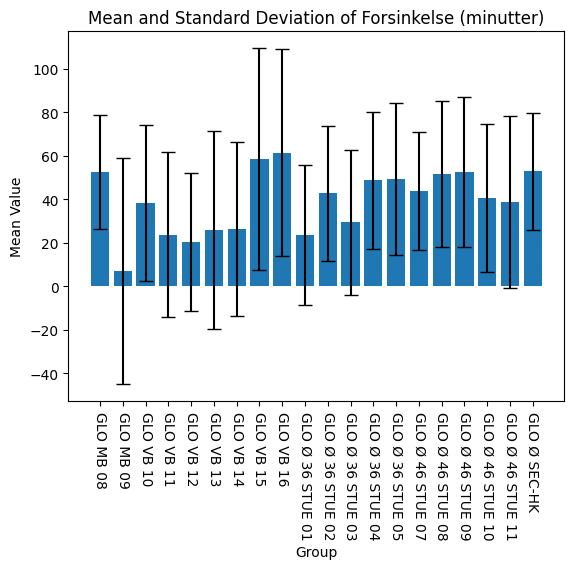

In [58]:
df_filtered = df_complete_wo[df_complete_wo['Operationsgang ID'] == 625]
dfs_filt = {k: v for k, v in df_filtered.groupby('Stue')}
column = 'Forsinkelse (minutter)'

keys = []
means = []
stds = []

for k, d in dfs_filt.items():
    keys.append(k)
    means.append(d[column].mean())
    stds.append(d[column].std())

plt.figure()
keys_str = [str(k) for k in keys]
plt.bar(keys_str, means, yerr=stds, capsize=5)

plt.xlabel("Group")
plt.ylabel("Mean Value")
plt.title(f"Mean and Standard Deviation of {column}")
plt.xticks(rotation=-90)

plt.show()

([<matplotlib.patches.Wedge at 0x27e19638cd0>,
 [Text(-1.0998962263486334, 0.015109310508294262, 'Øjenkirurgi'),
  Text(1.0998937419666623, -0.015289093582470728, 'Kirurgi'),
  Text(1.0999999669468408, -0.00026966080461123963, 'Plastikkirurgi'),
  Text(1.0999999963360403, -8.978146537372359e-05, 'Neurokirurgi')],
 [Text(-0.5999433961901636, 0.008241442095433232, '99.6%'),
  Text(0.5999420410727249, -0.008339505590438577, '0.4%'),
  Text(0.5999999819710039, -0.0001470877116061307, '0.0%'),
  Text(0.5999999980014764, -4.897170838566741e-05, '0.0%')])

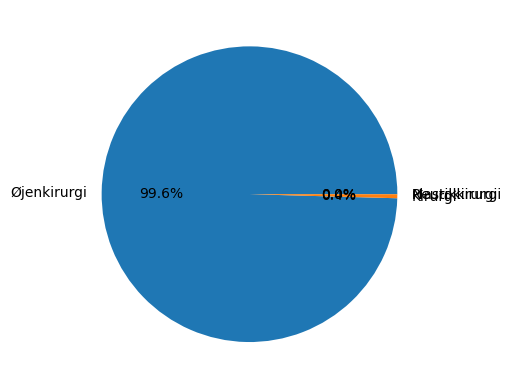

In [63]:
counts = df_filtered['Speciale'].value_counts()

plt.pie(counts, labels=counts.index, autopct='%1.1f%%')

([<matplotlib.patches.Wedge at 0x27e19d4ae60>,
 [Text(0.6270840599648146, 0.9037508405185829, 'Øjenkirurgi'),
  Text(-0.6986084184909015, 0.8496742185176868, 'Øre-næse-hals'),
  Text(-1.0377729255770543, 0.3647291528507725, 'Plastikkirurgi'),
  Text(-1.0986527441138236, -0.05442561760021871, 'Rygkirurgi'),
  Text(-1.0197939718011602, -0.4123351247201902, 'Neurokirurgi'),
  Text(-0.848254979622325, -0.7003309857102777, 'Tand- mund- og kæbekirurgi'),
  Text(-0.6234114804643798, -0.9062881032128859, 'Karkirurgi'),
  Text(-0.3719186530681836, -1.03521810045031, 'Thoraxkirurgi'),
  Text(-0.10716830905244804, -1.09476707729765, 'Kirurgi'),
  Text(0.15329258887074856, -1.0892664422432667, 'Hjertekirurgi'),
  Text(0.3905898554791584, -1.0283188050389676, 'Gynækologi'),
  Text(0.5990093604990334, -0.9225983882679067, 'Urologi'),
  Text(0.771969256247847, -0.7836220182001946, 'Børnekirurgi'),
  Text(0.8774885819243927, -0.6633353515321783, 'Gynækologi-obstetrik'),
  Text(0.9353818845397556, -0.5

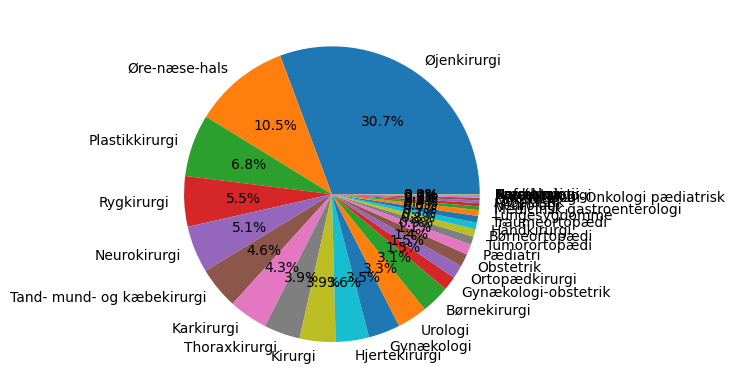

In [62]:
counts_complete = df_complete['Speciale'].value_counts()

plt.pie(counts, labels=counts.index, autopct='%1.1f%%')

In [68]:
# Hvor meget øjnkirugi er der generelt set
counts['Øjenkirurgi']/counts_complete['Øjenkirurgi']

0.9360624449447

{'whiskers': [<matplotlib.lines.Line2D at 0x27e25c9a860>,
 'caps': [<matplotlib.lines.Line2D at 0x27e25c9ae00>,
 'boxes': [<matplotlib.lines.Line2D at 0x27e25c9a590>],
 'medians': [<matplotlib.lines.Line2D at 0x27e25c9b3a0>],
 'fliers': [<matplotlib.lines.Line2D at 0x27e25c9b670>],
 'means': []}

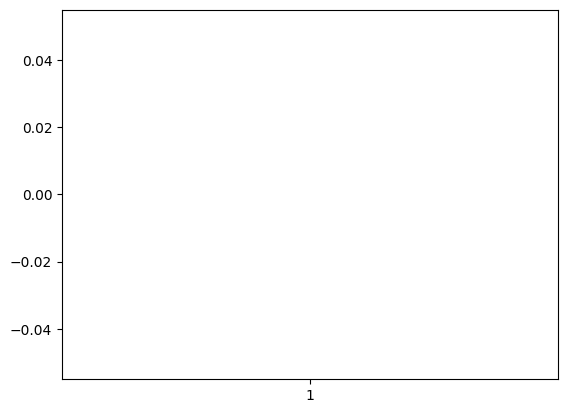

In [ ]:
# Hvor forskinket er den resterende øjnkirugi
group1 =  df_complete_wo[df_complete_wo['Operationsgang ID'] == 625]
group2 =  df_complete_wo[df_complete_wo['Operationsgang ID'] != 625]
group1 =  group1[group1['Speciale'] == 'Øjenkirurgi']["Forsinkelse (minutter)"]
group2 =  group2[group2['Speciale'] == 'Øjenkirurgi']["Forsinkelse (minutter)"]


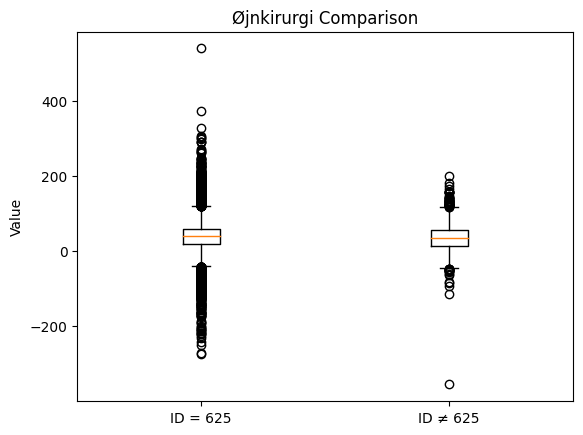

In [105]:
group1 = pd.to_numeric(group1, errors='coerce').dropna()
group2 = pd.to_numeric(group2, errors='coerce').dropna()
plt.boxplot([group1, group2], labels=['ID = 625', 'ID ≠ 625'])

plt.title('Øjnkirurgi Comparison')
plt.ylabel('Value')

plt.show()